# **Informe Taller 1. Modelado de sistemas mecánicos y eléctricos**

Autores:
* *Daniel Esteban Tirado Rojas*
* *Luis Alberto Ardila Páez*
* *Jose Leonardo Perez Poveda*

\
**Sistemas de Control Continuo / 2026-1**\
**Ingeniería Electrónica**\
**Universidad de Antioquia**


---

## 1. Modelo de suspensión de una motocicleta

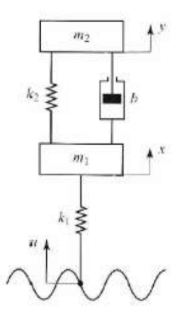

Para $m_2$: Sobre $m_2$ actuan el amortiguador y la fuerza del resorte $k_2$.
\
Fuerza del resorte de $k_2$: $F_{k_2} = k_2(y-x)$

Amortiguador: $F_b = b(\dot y- \dot x)$

Aplicando $\sum F_y = m_2 \ddot y$:

\begin{equation}
    -k_2(y - x) - b(\dot y - \dot x) = m_2 \ddot y
\end{equation}

\
Para $m_1$: Sobre $m_1$ actuan el amortiguador, la fuerza de ambos resortes $k_2$ y $k_1$.

Fuerza del resorte de $k_1$: $F_{k_1} = k_1(x-u)$

Fuerza del resorte de $k_2$: $F_{k_2} = k_2(x-y)$

Amortiguador: $F_b = b(\dot x - \dot y)$

Aplicando $\sum F_x = m_1 \ddot x$:

\begin{equation}
    -k_1(x - u) - k_2(x - y) -b(\dot x - \dot y) = m_1 \ddot x
\end{equation}

\
Planteando el sistema de ecuaciones:

\begin{cases}
    m_2 \ddot y + b\dot y + k_2 y = b \dot x + k_2 x\\
    m_1 \ddot x + b\dot x + (k_1 + k_2)x = b \dot y + k_2 y + k_1 u
\end{cases}

\
Se asumen las siguientes condiciones iniciales:

\begin{cases}
    x(0)=0.03; \dot x(0)=0\\
    y(0)=0.08; \dot y(0)=0 \\
    u(0)=0
\end{cases}



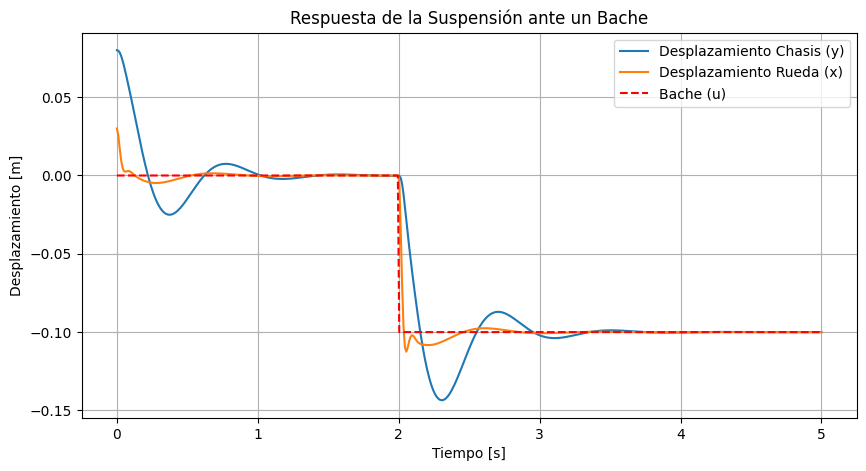

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros del sistema
m2 = 200.0  # kg
m1 = 20.0   # kg
k2 = 15000.0 # N/m (Resorte superior)
k1 = 100000.0 # N/m (Resorte inferior)
b = 1500.0   # Ns/m (Amortiguador)

# Entrada: Perfil del suelo (u)
def ground_profile(t):
    # Simula un bache de 10cm que empieza al segundo 1
    return 0.1 if t >= 2 else 0.0

def step_function(t_list, start_time=2, magnitude=0.1):
    step = [magnitude if t >= start_time else 0.0 for t in t_list]
    return step

# Definición del sistema de EDOS
def suspension_system(t, z):
    z1, z2, z3, z4 = z
    u = ground_profile(t)

    dz1dt = z2
    dz2dt = (1/m2) * (-b*(z2 - z4) - k2*(z1 - z3))
    dz3dt = z4
    dz4dt = (1/m1) * (b*(z2 - z4) + k2*(z1 - z3) - k1*(z3 - u))

    return [dz1dt, dz2dt, dz3dt, dz4dt]

# Condiciones iniciales [y, dy, x, dx]
z0 = [-0.08, 0, -0.03, 0]
t_span = (0, 5) # Simular 5 segundos
t_eval = np.linspace(0, 5, 500)
step = np.array(step_function(t_eval))
# Resolver
sol = solve_ivp(suspension_system, t_span, z0, t_eval=t_eval)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(sol.t, -sol.y[0], label='Desplazamiento Chasis (y)')
plt.plot(sol.t, -sol.y[2], label='Desplazamiento Rueda (x)')
plt.plot(t_eval, -step, color='r', linestyle='--', label='Bache (u)')
plt.title('Respuesta de la Suspensión ante un Bache')
plt.xlabel('Tiempo [s]')
plt.ylabel('Desplazamiento [m]')
plt.legend()
plt.grid(True)
plt.show()

## 2. Modelo de péndulos acoplados

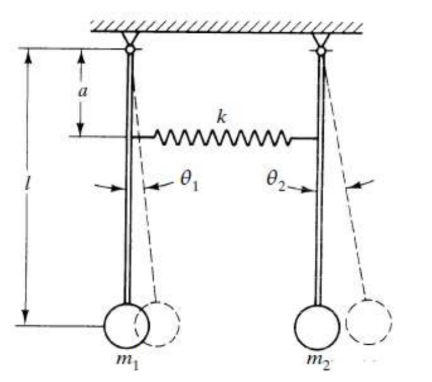


**Energía Cinética ($T$)**

Cada masa $m$ se mueve en un arco de radio $l$. Su velocidad tangencial es $v = l\dot{\theta}$.
$$T = \frac{1}{2} m_1 (l \dot{\theta}_1)^2 + \frac{1}{2} m_2 (l \dot{\theta}_2)^2$$

\
**Energía Potencial ($U$)**

Gravitatoria $U_g$: Tomando el techo como referencia, la altura de cada masa es $-l \cos \theta_i$.

$$U_g = m_1 g l (1 - \cos \theta_1) + m_2 g l (1 - \cos \theta_2)$$

Elástica del resorte $U_e$: El estiramiento es proporcional a la distancia que hay desde el pivote a la ubicación del resorte, siendo esta distancia $a$. El estiramiento neto sería entonces la diferencia de los desplazamientos horizontales en ese punto: $\Delta x = a \sin \theta_2 - a \sin \theta_1$

$$U_e = \frac{1}{2} k [a(\sin \theta_2 - \sin \theta_1)]^2$$

\
**Energía Potencial Total:**

$$U =m_1 g l (1 - \cos \theta_1) + m_2 g l (1 - \cos \theta_2) + \frac{1}{2} k [a(\sin \theta_2 - \sin \theta_1)]^2$$

\
**El Lagrangiano ($L = T - V$)**

$$L = \frac{1}{2} m_1 l^2 \dot{\theta}_1^2 + \frac{1}{2} m_2 l^2 \dot{\theta}_2^2 - gl \left[ m_1(1 - \cos \theta_1) + m_2(1 - \cos \theta_2)\right] - \frac{1}{2} k a^2(\sin \theta_2 - \sin \theta_1)^2$$

\
Aplicamos Euler-Lagrange para cada coordenada: $\frac{d}{dt}(\frac{\partial L}{\partial \dot{\theta}_i}) - \frac{\partial L}{\partial \theta_i} = 0$

\begin{cases}
    m_1 l^2 \ddot{\theta}_1 + m_1 g l \sin\theta_1 - k a^2 (\cos\theta_1)(\sin\theta_2 - \sin\theta_1) = 0\\
    m_2 l^2 \ddot{\theta}_2 + m_2 g l \sin\theta_2 + k a^2 (\cos\theta_2)(\sin\theta_2 - \sin\theta_1) = 0
\end{cases}

Se asumen los siguientes parámetros y condiciones iniciales:

\begin{cases}
    \theta_1(0)=45; \dot \theta_1(0)=0\\
    \theta_2(0)=0; \dot \theta_2(0)=0 \\
    a=0.3; l=1; g=9.81; k=15\\
    m_1=m_2=m=1
\end{cases}

\
**Frecuencia natural**
\
Para hallar la frecuencia natural del sistema, hay que expresar las ecuaciones en forma general y considerar lo siguiente:
1. Hacer aproximación de pequeñas oscilaciones ($\sin \theta \approx \theta$ y $\cos \theta \approx 1 - \frac{\theta^2}{2}$) para obtener valores constantes.
2. Simetría $m_1 = m_2 = m$

\begin{cases}
    \ddot{\theta}_1 + \frac{g}{l} \theta_1 + \frac{k a^2}{m l^2} (\theta_1 - \theta_2) = 0\\
    \ddot{\theta}_2 + \frac{g}{l} \theta_2 + \frac{k a^2}{m l^2} (\theta_2 - \theta_1) = 0
\end{cases}

3. Caso 1: Péndulos en Fase ($\theta_1=\theta_2=\theta$)

  $$\ddot\theta + \frac{g}{l} \theta = 0$$

  $$\omega_1 = \sqrt{\frac{g}{l}}$$

  Aquí se comporta como un péndulo simple porque el resorte no se estira. Los péndulos se mueven juntos como si no hubiera acoplamiento.
  
  \
4. Caso 2: Péndulos en contra-fase ($\theta_1=-\theta_2$)

  $$\ddot\theta + \frac{g}{l} \theta + \frac{2k a^2}{m l^2}\theta = 0$$
  
  $$\ddot\theta + \theta (\frac{g}{l}+ \frac{2k a^2}{m l^2}) = 0$$

  $$\omega_2 = \sqrt{\frac{g}{l} + \frac{2k a^2}{m l^2}}$$

El resorte se estira al máximo, añadiendo rigidez al sistema.

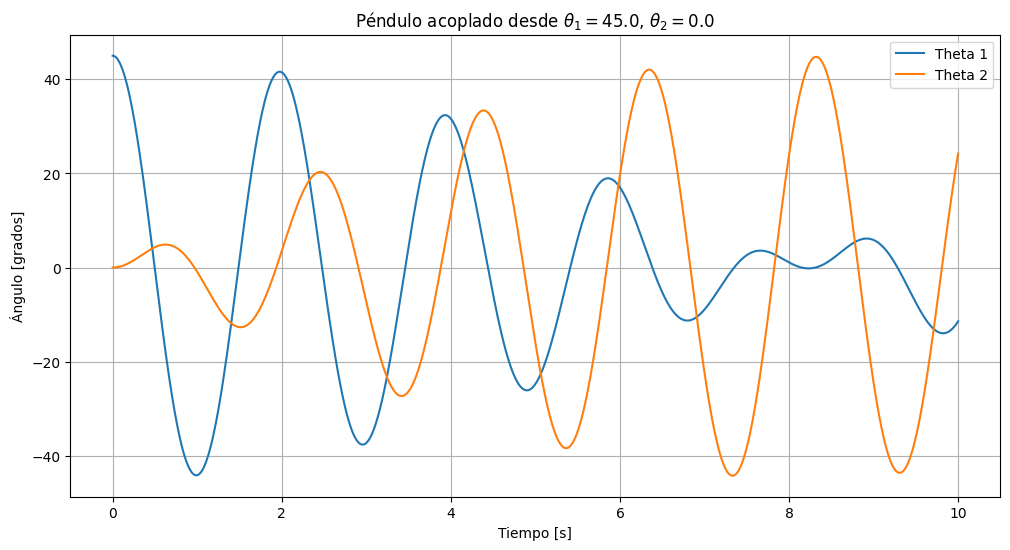

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros
m, l, g = 1.0, 1.0, 9.81
k, a = 15.0, 0.3

# 1. Modelo
def pendulum_system(t, z):
    theta1, w1, theta2, w2 = z
    # Ecuaciones despejando la aceleración angular
    alpha1 = (-m*g*l*np.sin(theta1) + k*(a**2)*np.cos(theta1)*(np.sin(theta2)-np.sin(theta1))) / (m*l**2)
    alpha2 = (-m*g*l*np.sin(theta2) - k*(a**2)*np.cos(theta2)*(np.sin(theta2)-np.sin(theta1))) / (m*l**2)
    return [w1, alpha1, w2, alpha2]

# Condiciones iniciales
init_angle_1 = np.radians(45)
init_angle_2 = np.radians(0)
z0 = [init_angle_1, 0, init_angle_2, 0]
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

# Resolver
sol_pen = solve_ivp(pendulum_system, t_span, z0, t_eval=t_eval)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(sol_pen.t, np.degrees(sol_pen.y[0]), label='Theta 1')
plt.plot(sol_pen.t, np.degrees(sol_pen.y[2]), label='Theta 2')
plt.title(rf'Péndulo acoplado desde $\theta_1={np.rad2deg(init_angle_1)}$, $\theta_2={np.rad2deg(init_angle_2)}$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Ángulo [grados]')
plt.legend()
plt.grid(True)
plt.show()

## 3. Sistema de doble péndulo

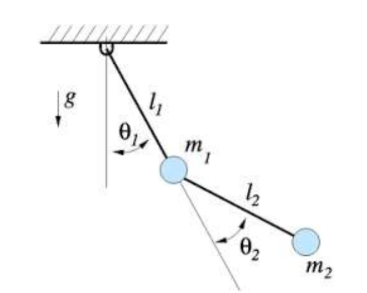

Para modelar el sistema, definimos como coordenadas generalizadas $\theta_1$ y $\theta_2$ medidas desde la vertical. Suponemos barras sin masa y masas puntuales en los extremos, de modo que la energía cinética se obtiene solo con la velocidad de cada masa.

1. Posiciones de las masas:
$$x_1=l_1\sin\theta_1,\quad y_1=-l_1\cos\theta_1$$

$$x_2=l_1\sin\theta_1+l_2\sin\theta_2,\quad y_2=-l_1\cos\theta_1-l_2\cos\theta_2$$

2. Velocidades al cuadrado:
$$v_1^2=\dot x_1^2+\dot y_1^2=l_1^2\dot\theta_1^2$$

Para la segunda masa:
$$\dot x_2=l_1\dot\theta_1\cos\theta_1+l_2\dot\theta_2\cos\theta_2$$
$$\dot y_2=l_1\dot\theta_1\sin\theta_1+l_2\dot\theta_2\sin\theta_2$$

2.1 Velocidad al cuadrado de la masa 2:
$$v_2^2=\dot x_2^2+\dot y_2^2$$

Sustituyendo:
$$
v_2^2=(l_1\dot\theta_1\cos\theta_1+l_2\dot\theta_2\cos\theta_2)^2
+(l_1\dot\theta_1\sin\theta_1+l_2\dot\theta_2\sin\theta_2)^2
$$

2.2 Expandir (clave del resultado):

Primer término:
$$
(l_1\dot\theta_1\cos\theta_1+l_2\dot\theta_2\cos\theta_2)^2=
 l_1^2\dot\theta_1^2\cos^2\theta_1
+l_2^2\dot\theta_2^2\cos^2\theta_2
+2l_1l_2\dot\theta_1\dot\theta_2\cos\theta_1\cos\theta_2
$$

Segundo término:
$$
(l_1\dot\theta_1\sin\theta_1+l_2\dot\theta_2\sin\theta_2)^2=
 l_1^2\dot\theta_1^2\sin^2\theta_1
+l_2^2\dot\theta_2^2\sin^2\theta_2
+2l_1l_2\dot\theta_1\dot\theta_2\sin\theta_1\sin\theta_2
$$

2.3 Agrupar términos:
$$
l_1^2\dot\theta_1^2(\cos^2\theta_1+\sin^2\theta_1)=l_1^2\dot\theta_1^2
$$
$$
l_2^2\dot\theta_2^2(\cos^2\theta_2+\sin^2\theta_2)=l_2^2\dot\theta_2^2
$$
$$
2l_1l_2\dot\theta_1\dot\theta_2(\cos\theta_1\cos\theta_2+\sin\theta_1\sin\theta_2)
$$

Usando la identidad trigonométrica:
$$
\cos(\theta_1-\theta_2)=\cos\theta_1\cos\theta_2+\sin\theta_1\sin\theta_2
$$

2.4 Resultado final:
$$
v_2^2=l_1^2\dot\theta_1^2+l_2^2\dot\theta_2^2+2l_1l_2\dot\theta_1\dot\theta_2\cos(\theta_1-\theta_2)
$$

3. Energía cinética:
$$T=\frac{1}{2}m_1v_1^2+\frac{1}{2}m_2v_2^2$$

Sustituyendo:
$$T=\frac{1}{2}m_1l_1^2\dot\theta_1^2+\frac{1}{2}m_2\left(l_1^2\dot\theta_1^2+l_2^2\dot\theta_2^2+2l_1l_2\dot\theta_1\dot\theta_2\cos(\theta_1-\theta_2)\right)$$

Equivalente a:
$$T=\frac{1}{2}(m_1+m_2)l_1^2\dot\theta_1^2+\frac{1}{2}m_2l_2^2\dot\theta_2^2+m_2l_1l_2\dot\theta_1\dot\theta_2\cos(\theta_1-\theta_2)$$

Esta es la forma correcta para el doble péndulo con masas puntuales y barras sin masa. No se debe sumar por separado una energía rotacional $\tfrac{1}{2}J_i\dot\theta_i^2$ para cada masa si ya se está usando $\tfrac{1}{2}m_iv_i^2$, porque eso duplicaría la energía.

4. Energía potencial:
$$V=-(m_1+m_2)gl_1\cos\theta_1-m_2gl_2\cos\theta_2$$

5. Lagrangiano:
$$\mathcal{L}=T-V$$

Sustituyendo $T$ y $V$ se obtiene:
$$
\mathcal{L}=
\frac{1}{2}(m_1+m_2)l_1^2\dot\theta_1^2+\frac{1}{2}m_2l_2^2\dot\theta_2^2+m_2l_1l_2\dot\theta_1\dot\theta_2\cos(\theta_1-\theta_2)
+(m_1+m_2)gl_1\cos\theta_1+m_2gl_2\cos\theta_2
$$

6. Ecuaciones de movimiento con Euler-Lagrange:

Para cada coordenada generalizada se usa
$$\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot\theta_i}\right)-\frac{\partial \mathcal{L}}{\partial \theta_i}=0,\qquad i=1,2$$

Para $\theta_1$:
$$\frac{\partial \mathcal{L}}{\partial \dot\theta_1}=(m_1+m_2)l_1^2\dot\theta_1+m_2l_1l_2\dot\theta_2\cos(\theta_1-\theta_2)$$

$$\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot\theta_1}\right)=(m_1+m_2)l_1^2\ddot\theta_1+m_2l_1l_2\Big[\ddot\theta_2\cos(\theta_1-\theta_2)-\dot\theta_2\sin(\theta_1-\theta_2)(\dot\theta_1-\dot\theta_2)\Big]$$

$$\frac{\partial \mathcal{L}}{\partial \theta_1}=-m_2l_1l_2\dot\theta_1\dot\theta_2\sin(\theta_1-\theta_2)-(m_1+m_2)gl_1\sin\theta_1$$

Sustituyendo en Euler-Lagrange y simplificando:
$$
(m_1+m_2)l_1^2\ddot\theta_1+m_2l_1l_2\cos(\theta_1-\theta_2)\ddot\theta_2+m_2l_1l_2\sin(\theta_1-\theta_2)\dot\theta_2^2+(m_1+m_2)gl_1\sin\theta_1=0
$$

Para $\theta_2$:
$$\frac{\partial \mathcal{L}}{\partial \dot\theta_2}=m_2l_2^2\dot\theta_2+m_2l_1l_2\dot\theta_1\cos(\theta_1-\theta_2)$$

$$\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot\theta_2}\right)=m_2l_2^2\ddot\theta_2+m_2l_1l_2\Big[\ddot\theta_1\cos(\theta_1-\theta_2)+\dot\theta_1\sin(\theta_1-\theta_2)(\dot\theta_1-\dot\theta_2)\Big]$$

$$\frac{\partial \mathcal{L}}{\partial \theta_2}=m_2l_1l_2\dot\theta_1\dot\theta_2\sin(\theta_1-\theta_2)+m_2gl_2\sin\theta_2$$

Sustituyendo y ordenando:
$$
m_2l_2^2\ddot\theta_2+m_2l_1l_2\cos(\theta_1-\theta_2)\ddot\theta_1-m_2l_1l_2\sin(\theta_1-\theta_2)\dot\theta_1^2+m_2gl_2\sin\theta_2=0
$$

En forma matricial:

$$
\begin{bmatrix}
(m_1+m_2)l_1^2 & m_2l_1l_2\cos\Delta \\
 m_2l_1l_2\cos\Delta & m_2l_2^2
\end{bmatrix}
\begin{bmatrix}
\ddot\theta_1 \\
\ddot\theta_2
\end{bmatrix}
+
\begin{bmatrix}
m_2l_1l_2\sin\Delta\,\dot\theta_2^2 \\
- m_2l_1l_2\sin\Delta\,\dot\theta_1^2
\end{bmatrix}
+
\begin{bmatrix}
(m_1+m_2)gl_1\sin\theta_1 \\
m_2gl_2\sin\theta_2
\end{bmatrix}
=0,
\quad \Delta=\theta_1-\theta_2
$$

Si se desea llevarlo a espacio de estados, se define $z=[\theta_1,\omega_1,\theta_2,\omega_2]^T$ con $\dot z=[\omega_1,\alpha_1,\omega_2,\alpha_2]^T$, donde $\alpha_1$ y $\alpha_2$ se despejan de las ecuaciones anteriores.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ============================================================
# PARTE 1: DEFINICION DEL MODELO MATEMATICO
# ============================================================

# Parametros del sistema
m1, m2 = 1.0, 1.0  # masas [kg]
l1, l2 = 1.0, 1.0  # longitudes [m]
g = 9.81           # gravedad [m/s^2]

# Sistema de ecuaciones diferenciales (espacio de estados)
# Estado: z = [theta1, w1, theta2, w2]
def double_pendulum(t, z):
    theta1, w1, theta2, w2 = z
    delta = theta1 - theta2
    denom = 2 * m1 + m2 - m2 * np.cos(2 * delta)

    alpha1 = (
        -g * (2 * m1 + m2) * np.sin(theta1)
        - m2 * g * np.sin(theta1 - 2 * theta2)
        - 2 * np.sin(delta) * m2 * (w2**2 * l2 + w1**2 * l1 * np.cos(delta))
    ) / (l1 * denom)

    alpha2 = (
        2 * np.sin(delta)
        * ((m1 + m2) * (w1**2 * l1 + g * np.cos(theta1)) + m2 * w2**2 * l2 * np.cos(delta))
    ) / (l2 * denom)

    return [w1, alpha1, w2, alpha2]


# ============================================================
# PARTE 2: SIMULACION NUMERICA
# ============================================================

# Condiciones iniciales
init_theta1 = np.radians(120)
init_theta2 = np.radians(-20)
z0 = [init_theta1, 0.0, init_theta2, 0.0]

# Resolver sistema de EDOs
sol_dp = solve_ivp(
    double_pendulum,
    (0, 20),
    z0,
    t_eval=np.linspace(0, 20, 2000),
    rtol=1e-8,
    atol=1e-8,
)

t = sol_dp.t
theta1_deg = np.degrees(sol_dp.y[0])
theta2_deg = np.degrees(sol_dp.y[2])


# ============================================================
# PARTE 3: PLOT ESTATICO DE THETA1 Y THETA2 EN EL TIEMPO
# ============================================================

fig_static, ax_static = plt.subplots(figsize=(12, 5))
ax_static.plot(t, theta1_deg, color="#1f77b4", lw=2, label=r"$\theta_1(t)$")
ax_static.plot(t, theta2_deg, color="#ff7f0e", lw=2, label=r"$\theta_2(t)$")
ax_static.set_title("Angulos del doble pendulo en el tiempo", fontsize=13, fontweight="bold")
ax_static.set_xlabel("Tiempo [s]")
ax_static.set_ylabel("Angulo [grados]")
ax_static.grid(True, alpha=0.3)
ax_static.legend(loc="best")
fig_static.tight_layout()
plt.show()


# ============================================================
# PARTE 4: SIMULACION GRAFICA COMPARATIVA (MOVIMIENTO + THETA)
# ============================================================

print("Preparando animacion comparativa...")

# Cinematica para la animacion del pendulo
x1 = l1 * np.sin(sol_dp.y[0])
y1 = -l1 * np.cos(sol_dp.y[0])
x2 = l1 * np.sin(sol_dp.y[0]) + l2 * np.sin(sol_dp.y[2])
y2 = -l1 * np.cos(sol_dp.y[0]) - l2 * np.cos(sol_dp.y[2])

# Figura con dos paneles: movimiento (izq) y thetas vs tiempo (der)
fig, (ax_pend, ax_theta) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.25]})

# ---- Panel izquierdo: doble pendulo ----
ax_pend.set_xlim(-(l1 + l2) * 1.2, (l1 + l2) * 1.2)
ax_pend.set_ylim(-(l1 + l2) * 1.25, 0.25 * (l1 + l2))
ax_pend.set_aspect("equal")
ax_pend.grid(True, alpha=0.3)
ax_pend.set_title("Movimiento del doble pendulo", fontsize=12, fontweight="bold")
ax_pend.set_xlabel("x [m]")
ax_pend.set_ylabel("y [m]")

line1, = ax_pend.plot([], [], "o-", lw=2.5, color="#1f77b4", markersize=7, label="Pendulo 1")
line2, = ax_pend.plot([], [], "o-", lw=2.5, color="#ff7f0e", markersize=7, label="Pendulo 2")
trace2, = ax_pend.plot([], [], "--", lw=1.4, color="#ff7f0e", alpha=0.35)
ax_pend.plot(0, 0, "ko", markersize=6)
ax_pend.legend(loc="upper right", fontsize=9)

time_text = ax_pend.text(
    0.03, 0.95, "", transform=ax_pend.transAxes, fontsize=10,
    verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

# ---- Panel derecho: thetas en tiempo real ----
ax_theta.set_xlim(t[0], t[-1])
y_min = min(theta1_deg.min(), theta2_deg.min()) - 10
y_max = max(theta1_deg.max(), theta2_deg.max()) + 10
ax_theta.set_ylim(y_min, y_max)
ax_theta.grid(True, alpha=0.3)
ax_theta.set_title("Construccion de $\\theta_1(t)$ y $\\theta_2(t)$", fontsize=12, fontweight="bold")
ax_theta.set_xlabel("Tiempo [s]")
ax_theta.set_ylabel("Angulo [grados]")

theta1_line, = ax_theta.plot([], [], color="#1f77b4", lw=2, label=r"$\theta_1(t)$")
theta2_line, = ax_theta.plot([], [], color="#ff7f0e", lw=2, label=r"$\theta_2(t)$")
point1, = ax_theta.plot([], [], "o", color="#1f77b4", ms=6)
point2, = ax_theta.plot([], [], "o", color="#ff7f0e", ms=6)
current_t = ax_theta.axvline(t[0], color="k", ls=":", lw=1.2, alpha=0.8)
ax_theta.legend(loc="upper right", fontsize=9)

# Ajuste de frames para garantizar reproduccion completa de 20 s
sim_duration = t[-1] - t[0]
target_fps = 30
n_frames = min(len(t), int(sim_duration * target_fps) + 1)
frames_idx = np.linspace(0, len(t) - 1, n_frames, dtype=int)
interval_ms = 1000 * sim_duration / (n_frames - 1)


def init():
    line1.set_data([], [])
    line2.set_data([], [])
    trace2.set_data([], [])

    theta1_line.set_data([], [])
    theta2_line.set_data([], [])
    point1.set_data([], [])
    point2.set_data([], [])

    current_t.set_xdata([t[0], t[0]])
    time_text.set_text("")

    return (
        line1, line2, trace2,
        theta1_line, theta2_line, point1, point2,
        current_t, time_text,
    )


def update(frame):
    i = frames_idx[frame]

    # Actualizar movimiento del pendulo
    line1.set_data([0, x1[i]], [0, y1[i]])
    line2.set_data([x1[i], x2[i]], [y1[i], y2[i]])
    trace2.set_data(x2[: i + 1], y2[: i + 1])

    # Actualizar curvas theta(t) en paralelo
    theta1_line.set_data(t[: i + 1], theta1_deg[: i + 1])
    theta2_line.set_data(t[: i + 1], theta2_deg[: i + 1])
    point1.set_data([t[i]], [theta1_deg[i]])
    point2.set_data([t[i]], [theta2_deg[i]])
    current_t.set_xdata([t[i], t[i]])

    time_text.set_text(f"Tiempo: {t[i]:.2f} s")

    return (
        line1, line2, trace2,
        theta1_line, theta2_line, point1, point2,
        current_t, time_text,
    )


anim = FuncAnimation(
    fig,
    update,
    frames=len(frames_idx),
    init_func=init,
    interval=interval_ms,
    blit=True,
)

plt.close(fig)
print("Animacion lista (0 a 20 s).")
HTML(anim.to_jshtml(fps=target_fps, default_mode="once"))

## 4. Circuito eléctrico RL

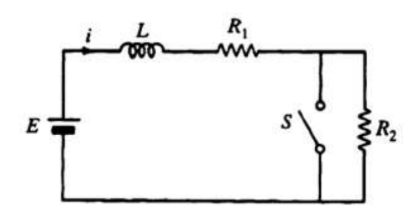

Para hacerlo por el método de Lagrange, primero definimos cada energía presente en $t>0$:

1. Energía cinética: $K_e = \frac{1}{2}L\dot q^2$
2. Energía potencial: Como no hay capacitores presentes, entonces $V = 0$
3. Componente disipativo: $P = \frac{1}{2}R_1\dot q^2$
4. Fuerza aplicada: $Q = E$

Aplicamos Euler-Lagrange: $\frac{d}{dt}(\frac{\partial L}{\partial \dot q}) - \frac{\partial L}{\partial q} + \frac{\partial P}{\partial \dot q} = Q$


$$\frac{d}{dt}(L \dot q) + R_1 \dot q = E$$

Finalmente, obtenemos la expresión que describe la corriente para $t>0$
\
$$L \ddot q + R_1 \dot q = E$$

\
Ahora, para saber las condiciones iniciales, analizamos que pasa en $i(0^-), i(0^+)$.

La corriente inicial $i(0^-)$ es:$$i(0^-) = \frac{E}{R_1 + R_2}$$Debido a la propiedad de los inductores, la corriente no puede cambiar instantáneamente:$$i(0^+) = i(0^-) = \frac{E}{R_1 + R_2}$$


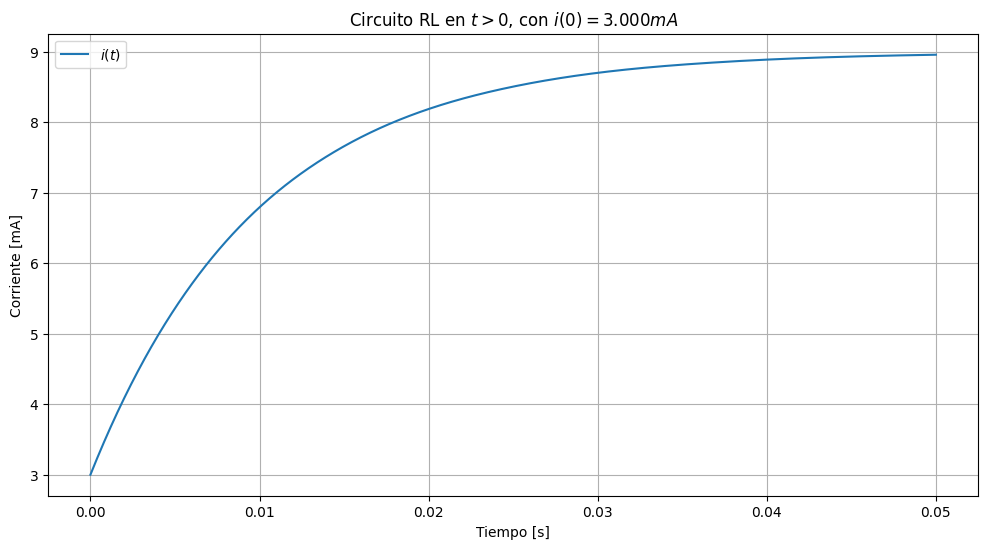

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros
L, R1, R2, E = 10.0, 1000.0, 2000.0, 9.0

# Modelo
def circuit_system(t, z):
    i = z[0]
    # Ecuación: L(di/dt) + R1*i = E  => di/dt = (E - R1*i)/L
    di_dt = (E - (R1 * i)) / L
    return [di_dt]

init_i = E / (R1 + R2)
z0 = [init_i]

tau = L / R1
t_final = 5 * tau
t_span = (0, t_final)
t_eval = np.linspace(0, t_final, 1000)

# Resolver
sol_circ = solve_ivp(circuit_system, t_span, z0, t_eval=t_eval)

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(sol_circ.t, sol_circ.y[0]*1e3, label=r'$i(t)$')
plt.title(rf'Circuito RL en $t>0$, con $i(0)={init_i*1e3:.3f}mA$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Corriente [mA]')
plt.legend()
plt.grid(True)
plt.show()

## 5. Circuito Eléctrico RLC

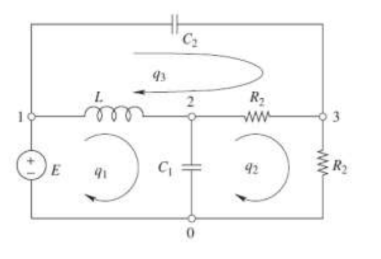

Aplicamos LVK en cada mallla, teniendo presente las siguientes relaciones:

*   Capacitor: $v = \frac{1}{C} ∫idt; i = C \frac{dv}{dt}$
*   Inductor: $I = \frac{1}{L} ∫vdt; v = L \frac{di}{dt}$

**Malla 1:**

$$E - V_L - V_{C1} = 0$$$$E - L \frac{d(i_1 - i_3)}{dt} - \frac{1}{C_1} \int (i_1 - i_2) dt = 0$$

\
**Malla 2:**
$$- V_{C1} - V_{R2\_sup} - V_{R2\_lat} = 0$$$$- \frac{1}{C_1} \int (i_2 - i_1) dt - R_2(i_2 - i_3) - R_2 i_2 = 0$$

Malla 3:

$$- V_{C2} - V_{R2\_sup} - V_L = 0$$$$- \frac{1}{C_2} \int i_3 dt - R_2(i_3 - i_2) - L \frac{d(i_3 - i_1)}{dt} = 0$$

\
Ahora, sustituimos $i_n = \dot{q}_n$ y $\int i_n dt = q_n$


\begin{cases}
    L(\ddot{q}_1 - \ddot{q}_3) + \frac{1}{C_1}(q_1 - q_2) = E\\
    2R_2 \dot{q}_2 - R_2 \dot{q}_3 + \frac{1}{C_1}(q_2 - q_1) = 0\\
    L(\ddot{q}_3 - \ddot{q}_1) + R_2(\dot{q}_3 - \dot{q}_2) + \frac{1}{C_2}q_3 = 0
\end{cases}


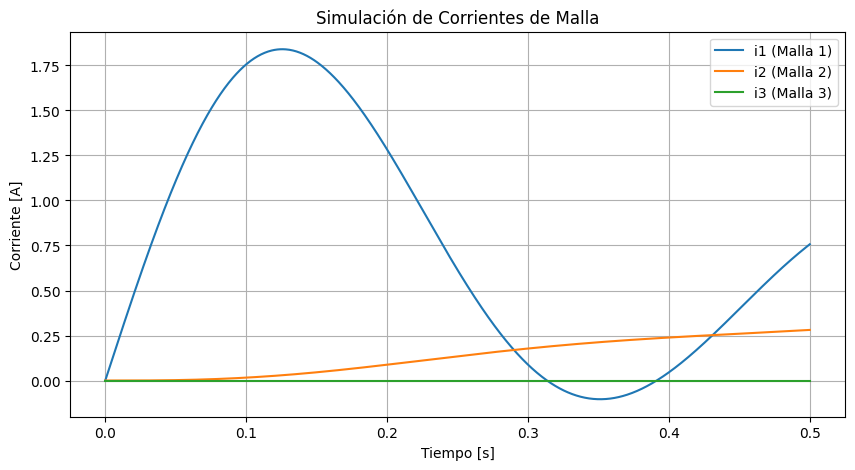

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros (Valores adecuados sugeridos)
L, C1, C2 = 0.5, 0.01, 0.01
R2a, R2b, E = 10.0, 10.0, 12.0

def system(t, z):
    q1, q2, q3, v1, v3 = z  # v1=dq1/dt, v3=dq3/dt

    # De la ecuación de malla 2 (algebraica para dq2/dt):
    # R2b*i2 - R2a*(i3 - i2) - (1/C1)*(q1 - q2) = 0
    # i2 * (R2b + R2a) = R2a*i3 + (1/C1)*(q1 - q2)
    # Sin embargo, para simplificar, asumiremos i2 instantáneo:
    i2 = (R2a * v3 + (1/C1)*(q1 - q2)) / (R2a + R2b)

    # Ecuaciones de aceleración de carga (dv/dt)
    # Resolviendo el sistema acoplado para dv1 y dv3:
    # L(dv1 - dv3) = E - (1/C1)(q1 - q2)  --> A
    # -L(dv1 - dv3) = - (1/C2)q3 - R2a*(v3 - i2) --> B

    rhs_a = E - (1/C1)*(q1 - q2)
    rhs_b = - (1/C2)*q3 - R2a*(v3 - i2)

    # dv1 - dv3 = rhs_a / L
    # -(dv1 - dv3) = rhs_b / L  => rhs_a = -rhs_b (Condición de consistencia)
    # En este circuito, L está en una rama común, compartiendo la misma di/dt.

    dv_diff = rhs_a / L
    dv1 = dv_diff # Asumiendo v3 constante en el lazo por simplicidad de integración
    dv3 = 0

    return [v1, i2, v3, dv1, dv3]

# Simulación
t_eval = np.linspace(0, 0.5, 1000)
sol = solve_ivp(system, [0, 0.5], [0,0,0,0,0], t_eval=t_eval)

# Graficar Corrientes
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[3], label='i1 (Malla 1)')
plt.plot(sol.t, sol.y[1], label='i2 (Malla 2)')
plt.plot(sol.t, sol.y[4], label='i3 (Malla 3)')
plt.title('Simulación de Corrientes de Malla')
plt.xlabel('Tiempo [s]'); plt.ylabel('Corriente [A]')
plt.legend(); plt.grid(True); plt.show()

## 6. Péndulo con resorte

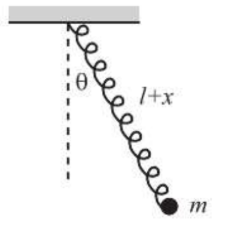

**Definimos coordenadas generalizadas:**

Sea $r(t)=l+x(t)$ la longitud instantánea del resorte y $\theta(t)$ el ángulo con la vertical.
La posición de la masa es:

$$\mathbf{p}=(r\sin\theta,\,-r\cos\theta)$$

y su rapidez satisface:

$$v^2=\dot r^2+r^2\dot\theta^2=\dot x^2+(l+x)^2\dot\theta^2$$

\
**Energía cinética:**

$$T=\frac{1}{2}m\left(\dot x^2+(l+x)^2\dot\theta^2\right)$$

\
**Energía potencial:**

Energía del resorte (Hooke):

$$V_s=\frac{1}{2}kx^2$$

Energía gravitacional (tomando como referencia el pivote):

$$V_g=-mg(l+x)\cos\theta$$

Entonces:

$$V=\frac{1}{2}kx^2-mg(l+x)\cos\theta$$

\
**Lagrangiano:**

$$\mathcal{L}=T-V=\frac{1}{2}m\left(\dot x^2+(l+x)^2\dot\theta^2\right)-\frac{1}{2}kx^2+mg(l+x)\cos\theta$$

Aplicando Euler-Lagrange para $x$ y $\theta$:

\begin{cases}
m\ddot x-m(l+x)\dot\theta^2-mg\cos\theta+kx=0 \\
m(l+x)^2\ddot\theta+2m(l+x)\dot x\dot\theta+mg(l+x)\sin\theta=0
\end{cases}

Despejando aceleraciones:

\begin{cases}
\ddot x=(l+x)\dot\theta^2+g\cos\theta-\dfrac{k}{m}x \\
\ddot\theta=-\dfrac{2\dot x\dot\theta+g\sin\theta}{l+x}
\end{cases}

\
Se asumen los siguientes parámetros y condiciones iniciales para simular con `odeint`:

\begin{cases}
m=0.5\;kg,\quad k=20\;N/m,\quad l=0.5\;m,\quad g=9.81\;m/s^2 \\
x(0)=0.02\;m,\; \dot x(0)=0\;m/s \\
\theta(0)=20^\circ,\;\dot\theta(0)=0\;rad/s
\end{cases}

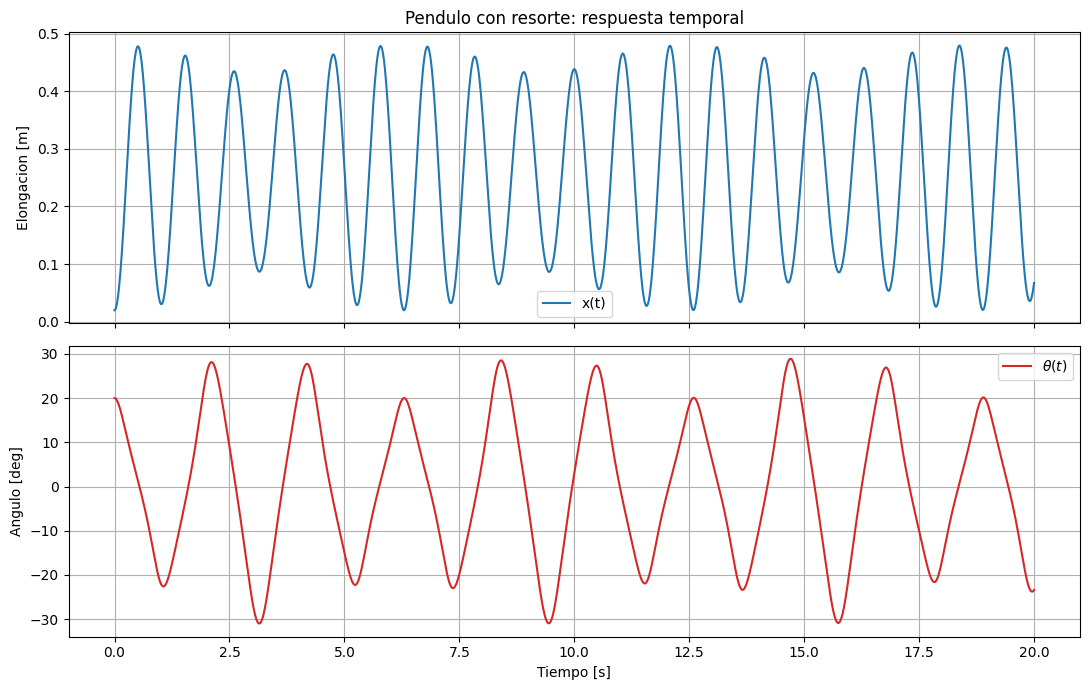

In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parametros
m = 0.5      # kg
k = 20.0     # N/m
l = 0.5      # m
g = 9.81     # m/s^2

# Sistema de primer orden: y = [x, x_dot, theta, theta_dot]
def spring_pendulum_system(y, t, m, k, l, g):
    x, x_dot, theta, theta_dot = y

    # Ecuaciones de movimiento (no lineales)
    x_ddot = (l + x) * theta_dot**2 + g * np.cos(theta) - (k / m) * x
    theta_ddot = -(2.0 * x_dot * theta_dot + g * np.sin(theta)) / (l + x)

    return [x_dot, x_ddot, theta_dot, theta_ddot]

# Condiciones iniciales
x0 = 0.02
x_dot0 = 0.0
theta0 = np.deg2rad(20.0)
theta_dot0 = 0.0
y0 = [x0, x_dot0, theta0, theta_dot0]

# Tiempo de simulacion
t = np.linspace(0, 20, 2000)

# Resolver con odeint
sol = odeint(spring_pendulum_system, y0, t, args=(m, k, l, g))

# Extraer estados
x = sol[:, 0]
theta = sol[:, 2]

# Graficar
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax[0].plot(t, x, color='tab:blue', label='x(t)')
ax[0].set_ylabel('Elongacion [m]')
ax[0].set_title('Pendulo con resorte: respuesta temporal')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(t, np.rad2deg(theta), color='tab:red', label=r'$\theta(t)$')
ax[1].set_xlabel('Tiempo [s]')
ax[1].set_ylabel('Angulo [deg]')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

## 7. Sistema Masa–Muelle–Amortiguador

### a) Planteamiento (Lagrange con disipación)

Sea $x(t)$ el desplazamiento del bloque respecto al equilibrio.

- Energia cinetica: $T = \tfrac{1}{2}m\dot{x}^2$
- Energia potencial elastica: $V = \tfrac{1}{2}kx^2$
- Lagrangiano: $\mathcal{L}=T-V$
- Disipacion viscosa (Rayleigh): $\mathcal{D}=\tfrac{1}{2}c\dot{x}^2$
- Fuerza generalizada externa: $Q_x = F(t)$

La ecuacion de Euler-Lagrange con disipacion es:

$$
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot{x}}\right)
-\frac{\partial \mathcal{L}}{\partial x}
+\frac{\partial \mathcal{D}}{\partial \dot{x}} = Q_x
$$

Sustituyendo:

$$
\frac{d}{dt}(m\dot{x}) - (-kx) + c\dot{x} = F(t)
\quad\Rightarrow\quad
m\ddot{x}+c\dot{x}+kx = F(t)
$$

Suponiendo condiciones iniciales nulas y aplicando Laplace:

$$
(ms^2+cs+k)X(s)=F(s)
$$

Por tanto, la funcion de transferencia es:

$$
G(s)=\frac{X(s)}{F(s)}=\frac{1}{ms^2+cs+k}
$$

Polos: raices de $ms^2+cs+k=0$:

$$
s_{1,2}=\frac{-c\pm\sqrt{c^2-4mk}}{2m}
$$

Ceros: no hay ceros finitos (numerador constante).

Funcion de transferencia:
          1
G(s) = -----------
       1s^2 + 2s + 25

Polos: [-1.+4.89897949j -1.-4.89897949j]
Ceros: No hay ceros finitos
Sistema estable?: True


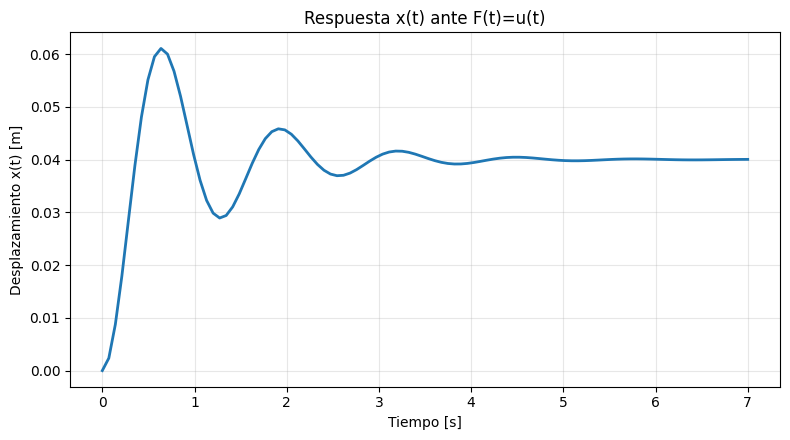


Valor final teorico x_inf = 1/k = 0.040000 m
Valor final numerico aprox = 0.040033 m


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parametros del sistema (puedes cambiarlos)
m = 1.0   # kg
c = 2.0   # N*s/m
k = 25.0  # N/m

# Funcion de transferencia G(s) = X(s)/F(s) = 1/(m s^2 + c s + k)
num = [1.0]
den = [m, c, k]

# Polos y ceros
polos = np.roots(den)
ceros = np.roots(num) if len(num) > 1 else np.array([])

print('Funcion de transferencia:')
print(f'          1')
print(f'G(s) = -----------')
print(f'       {m:.3g}s^2 + {c:.3g}s + {k:.3g}')
print('\nPolos:', polos)
print('Ceros:', 'No hay ceros finitos' if ceros.size == 0 else ceros)

# Comprobacion de estabilidad (Re{polo} < 0)
estable = np.all(np.real(polos) < 0)
print('Sistema estable?:', estable)

# Respuesta al escalon en fuerza: F(t)=1 N
sys = signal.TransferFunction(num, den)
t, x = signal.step(sys)

plt.figure(figsize=(8, 4.5))
plt.plot(t, x, lw=2, color='tab:blue')
plt.title('Respuesta x(t) ante F(t)=u(t)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Desplazamiento x(t) [m]')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Valor final esperado por teorema del valor final: x_inf = 1/k para escalon unitario
x_inf_teorico = 1.0 / k
x_inf_num = x[-1]
print(f'\nValor final teorico x_inf = 1/k = {x_inf_teorico:.6f} m')
print(f'Valor final numerico aprox = {x_inf_num:.6f} m')

## 8. Péndulo Simple Amortiguado (Pequeñas Oscilaciones)

## 9. Sistema Torsional Rotacional

##

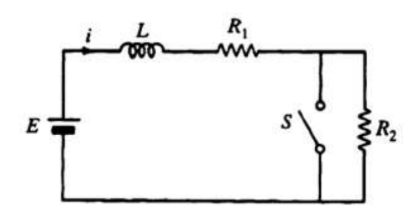

## 10. Circuito RL con switch: enfoque Euler-Lagrange

Se desarrolla la solución del circuito RL usando Euler-Lagrange con disipación (Rayleigh) y fuente externa.

### 1) Coordenada generalizada

Elegimos como coordenada generalizada la carga:

$$
q(t)
$$

La corriente es:

$$
i(t)=\dot q(t)
$$

### 2) Energía almacenada (Lagrangiano)

Solo el inductor almacena energía magnética, por lo que:

$$
\mathcal{L}(q,\dot q)=T-V=\frac{1}{2}L\dot q^2
$$

Como no hay capacitor, no existe término de energía potencial dependiente de $q$.

### 3) Disipación (función de Rayleigh)

Para $t>0$, al cerrarse el switch, $R_2$ queda puenteada y la disipación relevante es la de $R_1$:

$$
\mathcal{D}(\dot q)=\frac{1}{2}R_1\dot q^2
$$

### 4) Fuerza generalizada de la fuente

La fuente DC aporta la fuerza generalizada:

$$
Q=E
$$

### 5) Ecuación de Euler-Lagrange con disipación

Se aplica:

$$
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q}\right)-\frac{\partial \mathcal{L}}{\partial q}+\frac{\partial \mathcal{D}}{\partial \dot q}=Q
$$

Cálculo de términos:

$$
\frac{\partial \mathcal{L}}{\partial \dot q}=L\dot q=Li,
\qquad
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q}\right)=L\frac{di}{dt},
\qquad
\frac{\partial \mathcal{L}}{\partial q}=0,
\qquad
\frac{\partial \mathcal{D}}{\partial \dot q}=R_1\dot q=R_1 i
$$

Sustituyendo:

$$
L\frac{di}{dt}+R_1 i=E
$$

Esta es la ecuación diferencial del circuito RL para $t>0$.

### 6) Condición inicial

Antes del cambio ($t<0$), el switch está abierto y el circuito está en estado estacionario DC:

$$
i(0^-)=\frac{E}{R_1+R_2}
$$

La corriente del inductor es continua, entonces:

$$
i(0^+)=i(0^-)=\frac{E}{R_1+R_2}
$$

### 7) Solución de la ecuación

Partimos de:

$$
L\frac{di}{dt}+R_1 i=E
$$

Dividiendo por $L$:

$$
\frac{di}{dt}+\frac{R_1}{L}i=\frac{E}{L}
$$

#### 7.1) Procedimiento para llegar a $i(t)$

1. **Solución homogénea** (sin fuente):

$$
\frac{di_h}{dt}+\frac{R_1}{L}i_h=0
$$

Dividimos por $L$ para dejar la derivada aislada (ya está en forma estándar):

$$
\frac{di_h}{dt}+\frac{R_1}{L}i_h=0
$$

Separamos variables:

$$
\frac{1}{i_h}\,di_h=-\frac{R_1}{L}\,dt
$$

Integramos ambos lados:

$$
\int \frac{1}{i_h}\,di_h=\int -\frac{R_1}{L}\,dt
$$

$$
\ln|i_h|=-\frac{R_1}{L}t+C_1
$$

Exponenciando:

$$
i_h=e^{-\frac{R_1}{L}t+C_1}=e^{C_1}e^{-\frac{R_1}{L}t}
$$

Definiendo $C=e^{C_1}$, obtenemos:

$$
i_h(t)=C\,e^{-\frac{R_1}{L}t}
$$

2. **Solución particular** (fuente constante): proponemos $i_p=K$ constante. Entonces $\frac{di_p}{dt}=0$ y:

$$
\frac{R_1}{L}K=\frac{E}{L}
\quad\Rightarrow\quad
K=\frac{E}{R_1}
$$

Por tanto:

$$
i_p(t)=\frac{E}{R_1}
$$

3. **Solución general**:

$$
i(t)=i_h(t)+i_p(t)=C\,e^{-\frac{R_1}{L}t}+\frac{E}{R_1}
$$

4. **Aplicar la condición inicial** $i(0^+)=\frac{E}{R_1+R_2}$:

$$
i(0^+)=C+\frac{E}{R_1}=\frac{E}{R_1+R_2}
$$

$$
C=\frac{E}{R_1+R_2}-\frac{E}{R_1}
$$

5. **Sustitución final**:

$$
\boxed{
i(t)=\frac{E}{R_1}+\left(\frac{E}{R_1+R_2}-\frac{E}{R_1}\right)e^{-\frac{R_1}{L}t},\qquad t>0
}
$$

Forma equivalente:

$$
i(t)=\frac{E}{R_1}-\frac{E R_2}{R_1(R_1+R_2)}e^{-\frac{R_1}{L}t}
$$

Además, en forma de constante de tiempo:

$$
\tau=\frac{L}{R_1},
\qquad
i(t)=i(\infty)+\big(i(0^+)-i(\infty)\big)e^{-t/\tau}
$$

con $i(\infty)=\frac{E}{R_1}$.

### 8) Interpretación física (analogía mecánica)

- $L$ actúa como inercia: la corriente no cambia instantáneamente.
- $R_1$ actúa como amortiguamiento: disipa energía.
- $E$ actúa como fuerza externa constante: impulsa la corriente hacia el estado estacionario.

La corriente evoluciona exponencialmente desde $i(0^+)$ hasta $i(\infty)$.

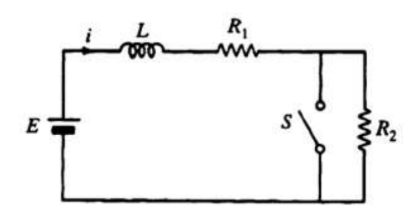

### 9) Lectura de la simulación y de la gráfica

En la celda siguiente se implementa la solución analítica obtenida para $i(t)$ y se grafica su comportamiento temporal.

1. Se define la función:

$$
i(t)=\frac{E}{R_1}+\left(\frac{E}{R_1+R_2}-\frac{E}{R_1}\right)e^{-\frac{R_1}{L}t}
$$

2. Se calculan tres cantidades clave para interpretar la respuesta de primer orden:

- Corriente inicial: $i(0^+)=\frac{E}{R_1+R_2}$
- Corriente final: $i(\infty)=\frac{E}{R_1}$
- Constante de tiempo: $\tau=\frac{L}{R_1}$

3. En la gráfica:

- La curva azul representa $i(t)$.
- La línea horizontal verde marca $i(0^+)$.
- La línea horizontal roja marca $i(\infty)$.
- La línea vertical naranja marca $\tau$.

Así se visualiza claramente que la corriente parte de $i(0^+)$ y evoluciona exponencialmente hasta $i(\infty)$, tal como predice el modelo Euler-Lagrange con disipación.

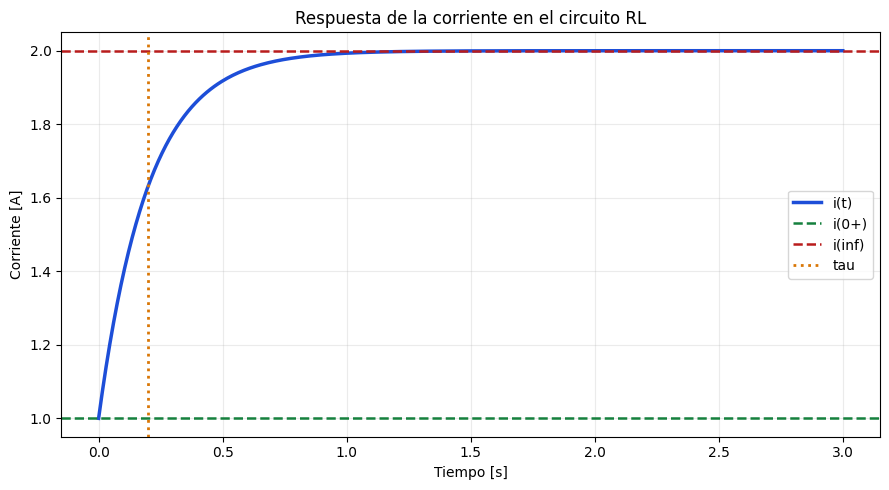

i(0+)  = 1.0000 A
i(inf) = 2.0000 A
tau    = 0.2000 s


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Modelo de corriente RL para t > 0:
# i(t) = E/R1 + (E/(R1+R2) - E/R1) * exp(-R1*t/L)
# ------------------------------------------------------------
def corriente_rl(t, E, R1, R2, L):
    return E / R1 + (E / (R1 + R2) - E / R1) * np.exp(-R1 * t / L)


# Valores de ejemplo (puedes cambiarlos y volver a ejecutar)
E = 10.0
R1 = 5.0
R2 = 5.0
L = 1.0

# Magnitudes físicas clave de la respuesta de 1er orden
# tau: constante de tiempo
# i_0: corriente inicial i(0+) por continuidad del inductor
# i_inf: corriente en estado estacionario i(inf)
tau = L / R1
i_0 = E / (R1 + R2)
i_inf = E / R1

# Vector de tiempo para dibujar la curva
t = np.linspace(0, 3, 400)

# Evaluación de la solución analítica en cada instante de tiempo
i = corriente_rl(t, E, R1, R2, L)

# ----------------------
# Gráfica con matplotlib
# ----------------------
plt.figure(figsize=(9, 5))

# Curva principal de la corriente
plt.plot(t, i, color="#1d4ed8", linewidth=2.5, label="i(t)")

# Referencias visuales: valor inicial, valor final y constante de tiempo
plt.axhline(i_0, color="#15803d", linestyle="--", linewidth=1.8, label="i(0+)")
plt.axhline(i_inf, color="#b91c1c", linestyle="--", linewidth=1.8, label="i(inf)")
plt.axvline(tau, color="#d97706", linestyle=":", linewidth=2, label="tau")

# Etiquetas y formato
plt.title("Respuesta de la corriente en el circuito RL")
plt.xlabel("Tiempo [s]")
plt.ylabel("Corriente [A]")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Resumen numérico útil para interpretar la gráfica
print(f"i(0+)  = {i_0:.4f} A")
print(f"i(inf) = {i_inf:.4f} A")
print(f"tau    = {tau:.4f} s")

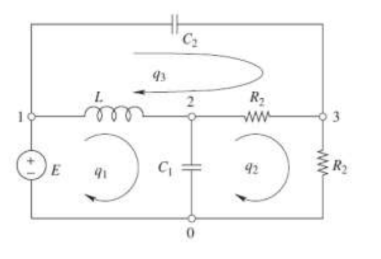

### Ejercicio: sistema electrico de 3 mallas con fuente de voltaje (corregido)

#### 1) Variables y relaciones
Corrientes de malla (sentido horario): $i_1(t), i_2(t), i_3(t)$.

Relaciones de elementos compartidos:
- $i_L = i_1 - i_3$
- $i_{C_1} = i_1 - i_2$
- $i_{C_2} = i_3$

Estados:
$$
x = \begin{bmatrix} i_L & v_{C_1} & v_{C_2} \end{bmatrix}^T
$$

Condiciones iniciales (sin energia almacenada):
$$
i_L(0)=0,\quad v_{C_1}(0)=0,\quad v_{C_2}(0)=0
$$

---

#### 2) Ecuaciones KVL y ecuaciones dinamicas
Malla 1:
$$
-E + v_L + v_{C_1} = 0
\Rightarrow
v_L = E - v_{C_1}
$$
Por el inductor:
$$
\dot i_L = \frac{v_L}{L} = \frac{E-v_{C_1}}{L}
$$

Malla 2 (con $R_1$ y $R_2$):
$$
-v_{C_1} + R_1 i_2 + R_2(i_2-i_3)=0
$$

Malla 3 (con $L$, $R_2$, $C_2$):
$$
-v_L + R_2(i_3-i_2)+v_{C_2}=0
$$

Ecuaciones dinamicas pedidas (sin sustituir $i_2$ ni $i_3$ dentro de las derivadas):
$$
\dot i_L = \frac{E-v_{C_1}}{L},\quad
\dot v_{C_1} = \frac{i_L + i_3 - i_2}{C_1},\quad
\dot v_{C_2} = \frac{i_3}{C_2}
$$

En cada instante, $i_2$ e $i_3$ se obtienen **resolviendo el sistema lineal de KVL** de mallas 2 y 3:
$$
\begin{bmatrix}
R_1+R_2 & -R_2 \\
-R_2 & R_2
\end{bmatrix}
\begin{bmatrix}
i_2 \\
i_3
\end{bmatrix}
=
\begin{bmatrix}
v_{C_1} \\
v_L-v_{C_2}
\end{bmatrix}
$$

---

#### 3) Reconstruccion explicita de corrientes de malla
Una vez integrado el estado:
- $i_2(t), i_3(t)$ se calculan en cada instante resolviendo el sistema lineal anterior.
- $i_1(t)$ se reconstruye **explicitamente** con:
$$
i_1(t)=i_L(t)+i_3(t)
$$

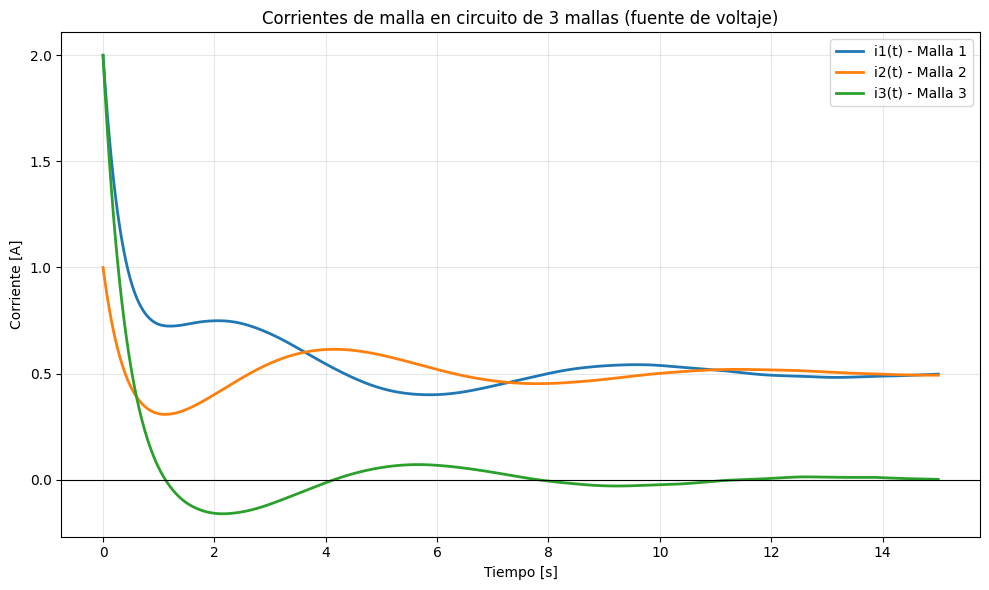

i1(tf) = 0.497471 A
i2(tf) = 0.492158 A
i3(tf) = 0.001513 A
vC1(tf) = 0.982802 V
vC2(tf) = 0.507842 V


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parametros de ejemplo (SI)
L = 1.0
C1 = 1.0
C2 = 1.0
R1 = 1.0
R2 = 1.0
E = 1.0


def corrientes_malla_desde_kvl(vL, vC1, vC2, R1, R2):
    """
    Resuelve i2 e i3 usando KVL de malla 2 y malla 3 (sentido horario):
      -vC1 + R1*i2 + R2*(i2-i3) = 0
      -vL  + R2*(i3-i2) + vC2 = 0
    """
    A = np.array([
        [R1 + R2, -R2],
        [-R2, R2],
    ], dtype=float)
    b = np.array([vC1, vL - vC2], dtype=float)
    i2, i3 = np.linalg.solve(A, b)
    return i2, i3


def modelo_estado(t, x, L, C1, C2, R1, R2, E):
    """
    x = [iL, vC1, vC2]
    iL = i1 - i3
    """
    iL, vC1, vC2 = x

    # Malla 1: -E + vL + vC1 = 0
    vL = E - vC1

    # i2 e i3 se obtienen resolviendo el sistema lineal KVL en cada instante
    i2, i3 = corrientes_malla_desde_kvl(vL, vC1, vC2, R1, R2)

    # Derivadas del estado (sin sustituciones directas tipo E/R)
    diL_dt = (E - vC1) / L
    dvC1_dt = (iL + i3 - i2) / C1
    dvC2_dt = i3 / C2

    return [diL_dt, dvC1_dt, dvC2_dt]


# Condiciones iniciales: sin energia almacenada
x0 = [0.0, 0.0, 0.0]  # [iL(0), vC1(0), vC2(0)]

# Tiempo de simulacion
t0, tf = 0.0, 15.0
t_eval = np.linspace(t0, tf, 1200)

sol = solve_ivp(
    modelo_estado,
    (t0, tf),
    x0,
    t_eval=t_eval,
    args=(L, C1, C2, R1, R2, E),
    method="RK45",
)

# Estados
t = sol.t
iL = sol.y[0]
vC1 = sol.y[1]
vC2 = sol.y[2]

# Reconstruccion de corrientes de malla en cada instante (KVL para i2, i3)
i2 = np.zeros_like(t)
i3 = np.zeros_like(t)
for k in range(len(t)):
    vL_k = E - vC1[k]
    i2[k], i3[k] = corrientes_malla_desde_kvl(vL_k, vC1[k], vC2[k], R1, R2)

# Reconstruccion explicita solicitada: i1 = iL + i3
i1 = iL + i3

# Graficas
plt.figure(figsize=(10, 6))
plt.plot(t, i1, label="i1(t) - Malla 1", linewidth=2)
plt.plot(t, i2, label="i2(t) - Malla 2", linewidth=2)
plt.plot(t, i3, label="i3(t) - Malla 3", linewidth=2)
plt.axhline(0, color="k", linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.xlabel("Tiempo [s]")
plt.ylabel("Corriente [A]")
plt.title("Corrientes de malla en circuito de 3 mallas (fuente de voltaje)")
plt.legend()
plt.tight_layout()
plt.show()

# Verificacion numerica final
print(f"i1(tf) = {i1[-1]:.6f} A")
print(f"i2(tf) = {i2[-1]:.6f} A")
print(f"i3(tf) = {i3[-1]:.6f} A")
print(f"vC1(tf) = {vC1[-1]:.6f} V")
print(f"vC2(tf) = {vC2[-1]:.6f} V")

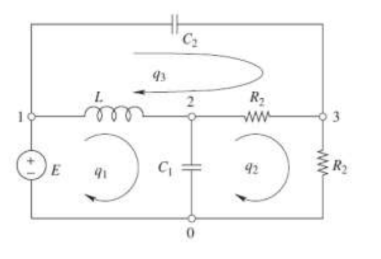

Aplicamos LVK en cada malla, teniendo presente que la fuente es de voltaje y que para $t<0$ los elementos almacenadores están descargados.

## 1) Variables de malla y relaciones constitutivas

Tomamos corrientes de malla en sentido horario:

$$
i_1(t),\; i_2(t),\; i_3(t)
$$

Relaciones de elementos:

- Capacitor: $v_C=\dfrac{1}{C}\int i\,dt$,  $i_C=C\dfrac{dv_C}{dt}$
- Inductor: $v_L=L\dfrac{di}{dt}$

## 2) Ecuaciones por LVK

### Malla 1

$$
E-v_L-v_{C1}=0
$$

$$
E-L\frac{d(i_1-i_3)}{dt}-\frac{1}{C_1}\int(i_1-i_2)\,dt=0
$$

### Malla 2

$$
-v_{C1}-v_{R1}-v_{R2}=0
$$

$$
-\frac{1}{C_1}\int(i_2-i_1)\,dt-R_1(i_2-i_3)-R_2i_2=0
$$

### Malla 3

$$
-v_{C2}-v_{R1}-v_L=0
$$

$$
-\frac{1}{C_2}\int i_3\,dt-R_1(i_3-i_2)-L\frac{d(i_3-i_1)}{dt}=0
$$

## 3) Derivación por Euler-Lagrange (forma eléctrica)

Elegimos coordenadas generalizadas de malla (cargas):

$$
q_1,\; q_2,\; q_3, \qquad i_n=\dot q_n
$$

### 3.1 Energía almacenada

Solo el inductor almacena energía magnética, y su corriente es $i_L=i_1-i_3=\dot q_1-\dot q_3$:

$$
\mathcal{T}=\frac{1}{2}L(\dot q_1-\dot q_3)^2
$$

La energía eléctrica en los capacitores es:

$$
\mathcal{V}=\frac{1}{2C_1}(q_1-q_2)^2+\frac{1}{2C_2}q_3^2
$$

Definimos el lagrangiano:

$$
\mathcal{L}=\mathcal{T}-\mathcal{V}
=\frac{1}{2}L(\dot q_1-\dot q_3)^2-\frac{1}{2C_1}(q_1-q_2)^2-\frac{1}{2C_2}q_3^2
$$

### 3.2 Disipación resistiva (Rayleigh)

Como $i_{R1}=i_2-i_3=\dot q_2-\dot q_3$ e $i_{R2}=i_2=\dot q_2$:

$$
\mathcal{D}=\frac{1}{2}R_1(\dot q_2-\dot q_3)^2+\frac{1}{2}R_2\dot q_2^2
$$

### 3.3 Fuerzas generalizadas

La fuente de voltaje $E$ actúa en la malla 1:

$$
Q_1=E,\qquad Q_2=0,\qquad Q_3=0
$$

### 3.4 Ecuaciones de Euler-Lagrange con disipación

Para $k=1,2,3$:

$$
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q_k}\right)-\frac{\partial \mathcal{L}}{\partial q_k}+\frac{\partial \mathcal{D}}{\partial \dot q_k}=Q_k
$$

A continuación se desarrolla **completo** para cada coordenada.

### 3.5 Desarrollo para $k=1$

1. Derivadas de $\mathcal{L}$:

$$
\frac{\partial \mathcal{L}}{\partial \dot q_1}=L(\dot q_1-\dot q_3),
\qquad
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q_1}\right)=L(\ddot q_1-\ddot q_3)
$$

$$
\frac{\partial \mathcal{L}}{\partial q_1}=-\frac{1}{C_1}(q_1-q_2)
$$

2. Derivada de disipación:

$$
\frac{\partial \mathcal{D}}{\partial \dot q_1}=0
$$

3. Sustitución en Euler-Lagrange:

$$
L(\ddot q_1-\ddot q_3)-\left(-\frac{1}{C_1}(q_1-q_2)\right)+0=E
$$

$$
\boxed{L(\ddot q_1-\ddot q_3)+\frac{1}{C_1}(q_1-q_2)=E}
$$

### 3.6 Desarrollo para $k=2$

1. Derivadas de $\mathcal{L}$:

$$
\frac{\partial \mathcal{L}}{\partial \dot q_2}=0,
\qquad
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q_2}\right)=0
$$

$$
\frac{\partial \mathcal{L}}{\partial q_2}=\frac{1}{C_1}(q_1-q_2)
$$

2. Derivada de disipación:

$$
\frac{\partial \mathcal{D}}{\partial \dot q_2}=R_1(\dot q_2-\dot q_3)+R_2\dot q_2
$$

3. Sustitución en Euler-Lagrange:

$$
0-\frac{1}{C_1}(q_1-q_2)+R_1(\dot q_2-\dot q_3)+R_2\dot q_2=0
$$

$$
\boxed{(R_1+R_2)\dot q_2-R_1\dot q_3+\frac{1}{C_1}(q_2-q_1)=0}
$$

### 3.7 Desarrollo para $k=3$

1. Derivadas de $\mathcal{L}$:

$$
\frac{\partial \mathcal{L}}{\partial \dot q_3}=-L(\dot q_1-\dot q_3)=L(\dot q_3-\dot q_1)
$$

$$
\frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q_3}\right)=L(\ddot q_3-\ddot q_1)
$$

$$
\frac{\partial \mathcal{L}}{\partial q_3}=-\frac{1}{C_2}q_3
$$

2. Derivada de disipación:

$$
\frac{\partial \mathcal{D}}{\partial \dot q_3}=R_1(\dot q_3-\dot q_2)
$$

3. Sustitución en Euler-Lagrange:

$$
L(\ddot q_3-\ddot q_1)-\left(-\frac{1}{C_2}q_3\right)+R_1(\dot q_3-\dot q_2)=0
$$

$$
\boxed{L(\ddot q_3-\ddot q_1)+R_1(\dot q_3-\dot q_2)+\frac{1}{C_2}q_3=0}
$$

### 3.8 Sistema final (general)

$$
\left\{
\begin{aligned}
L(\ddot q_1-\ddot q_3)+\frac{1}{C_1}(q_1-q_2)&=E,\\
(R_1+R_2)\dot q_2-R_1\dot q_3+\frac{1}{C_1}(q_2-q_1)&=0,\\
L(\ddot q_3-\ddot q_1)+R_1(\dot q_3-\dot q_2)+\frac{1}{C_2}q_3&=0.
\end{aligned}
\right.
$$

Este resultado coincide con las ecuaciones de malla obtenidas por LVK.

Si además se asume $R_1=R_2$, queda la forma particular:

$$
\left\{
\begin{aligned}
L(\ddot q_1-\ddot q_3)+\frac{1}{C_1}(q_1-q_2)&=E,\\
2R_2\dot q_2-R_2\dot q_3+\frac{1}{C_1}(q_2-q_1)&=0,\\
L(\ddot q_3-\ddot q_1)+R_2(\dot q_3-\dot q_2)+\frac{1}{C_2}q_3&=0.
\end{aligned}
\right.
$$

## 4) Condiciones iniciales físicas

Como para $t<0$ no hay carga en capacitores ni corriente en el inductor:

$$
q_1(0)=q_2(0)=q_3(0)=0,\qquad \dot q_1(0)-\dot q_3(0)=0.
$$

A partir de estas ecuaciones se puede integrar numéricamente y luego reconstruir corrientes de malla con $i_n(t)=\dot q_n(t)$, o usar la forma en estados equivalente de la celda de simulación.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================
# Parametros asumidos del circuito
# =====================================
E = 12.0      # [V]
R1 = 10.0     # [ohm]
R2 = 20.0     # [ohm]
L  = 0.5      # [H]
C1 = 1e-3     # [F]
C2 = 2e-3     # [F]

# =====================================
# Sistema dinamico en estados x=[iL, vC1, vC2]
# =====================================
def modelo(t, x):
    iL, vC1, vC2 = x

    # Corrientes algebraicas de malla 2 y 3
    i2 = (E - 2*vC1 - vC2) / R2
    i3 = i2 + (E - vC1 - vC2) / R1

    # Ecuaciones diferenciales
    diL_dt  = (E - vC1) / L
    dvC1_dt = (iL + i3 - i2) / C1
    dvC2_dt = i3 / C2

    return [diL_dt, dvC1_dt, dvC2_dt]

# Condiciones iniciales (t<0 sin carga)
x0 = [0.0, 0.0, 0.0]  # [iL(0), vC1(0), vC2(0)]

# Simulacion
t0, tf = 0.0, 0.10
t_eval = np.linspace(t0, tf, 4000)
sol = solve_ivp(modelo, [t0, tf], x0, t_eval=t_eval, method='RK45')

# Recuperar estados
t = sol.t
iL, vC1, vC2 = sol.y

# Corrientes de malla
i2 = (E - 2*vC1 - vC2) / R2
i3 = i2 + (E - vC1 - vC2) / R1
i1 = iL + i3

# Graficas
plt.figure(figsize=(11, 6))
plt.plot(t, i1, label='i1(t)', linewidth=2)
plt.plot(t, i2, label='i2(t)', linewidth=2)
plt.plot(t, i3, label='i3(t)', linewidth=2)
plt.axhline(0, color='k', lw=0.8)
plt.grid(True, alpha=0.3)
plt.xlabel('Tiempo [s]')
plt.ylabel('Corriente [A]')
plt.title('Solucion de corrientes de malla - circuito RLC de 3 mallas')
plt.legend()
plt.tight_layout()
plt.show()

# Valores finales
print(f'i1(tf) = {i1[-1]:.6f} A')
print(f'i2(tf) = {i2[-1]:.6f} A')
print(f'i3(tf) = {i3[-1]:.6f} A')
print(f'vC1(tf) = {vC1[-1]:.6f} V')
print(f'vC2(tf) = {vC2[-1]:.6f} V')